This notebook works with simulations for random network

In [ ]:
import numpy as np
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork

In [6]:
# Random distribution
np.random.seed(0)

# Set reference density of melt
rhoref = 2500

# Set limits of characteristic size of chamber
R_min = 500
R_max = 500
# Uniformly randomly distribution volume
V_min = (4/3)*np.pi*R_min**3
V_max = (4/3)*np.pi*R_max**3

# Network parameters
N_chamber = 10
x_scale = 10000.0
y_scale = 0.0
z_scale = 40000.0 # Depth

# List generation of chamber characteristics
x_nodes = 0.0 * np.random.rand(N_chamber)
y_nodes = 0.0 * np.random.rand(N_chamber)
z_nodes = np.linspace(0.0, z_scale, N_chamber)
V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

# Characteristic node separation distance
node_sep = z_scale/(N_chamber - 1)

list_nodes = [cnetwork.MagmaChamber(x=x, y=y, z=z,
  p_setting=None, vref=1.0/rhoref,
  T_setting=1000+273.15, V_setting=V)
  for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

In [7]:
global_sys = cnetwork.GlobalSystemThreshold(list_nodes,
  **cnetwork.default_props(),
  **cnetwork.default_numerics(),
  dpdx_crit=1e3, dpdx_threshold_scale=0.0, max_edge_dist=1.1*node_sep)

# Source term due to mass injection at node 0
f_inj = global_sys.create_single_mass_injection_source(3.0)
# Source term due to eruption at node -1
f_erupt = global_sys.create_eruption_source(p_erupt=5e6, mu_erupt=1e5, r_conduit=25)

In [13]:
t_vec = np.linspace(0, 10e11, 160000)
q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)

In [ ]:
m, p, u = global_sys.compute_m_p_u(q_out)

: 

In [ ]:
fig, axes = global_sys.make_composite_plot(t_vec, q_out, m_erupted_out, z_samples=200)
# Superimpose residence time plot
plt.sca(axes[4])
node_locs = global_sys.residence_time_sim(t_vec, q_out, N_particles=10000, add_legend=False)


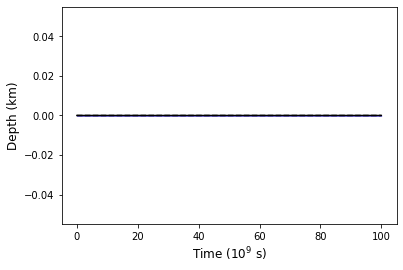

In [12]:
node_locs = global_sys.residence_time_sim(t_vec, q_out, N_particles=10000, add_legend=False)

Legacy

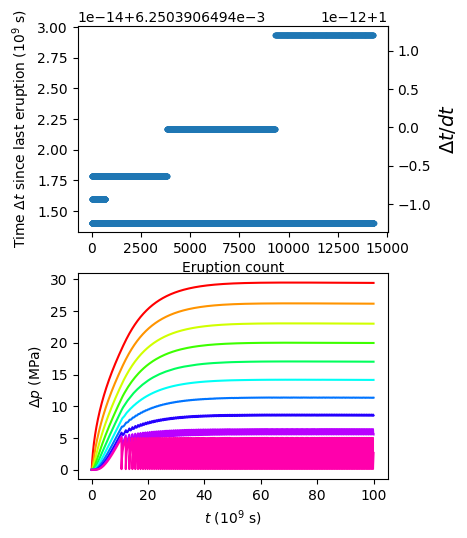

In [11]:
plt.figure(figsize=(4,6), dpi=100)

# Estimate dpdt
plt.subplot(2,1,1)
t_cell = 0.5 * (t_vec[:-1] + t_vec[1:])
dt_vec = t_vec[1:] - t_vec[:-1]
dpdt = np.diff(p[:,-1]) / dt_vec
t_idx_eruption = np.where(np.abs(dpdt) > 0.001)
plt.plot(np.diff(t_cell[t_idx_eruption])/1e9, '.')
plt.xlabel("Eruption count")
plt.ylabel("Time $\Delta t$ since last eruption ($10^9$ s)")
ax2y = plt.gca().secondary_yaxis('right', functions=(
  lambda t: t * 1e9 / (dt_vec[0]),
  lambda tau: tau * dt_vec[0] / 1e9))
ax2y.set_ylabel('$\Delta t/dt$', fontsize=14)

plt.subplot(2,1,2)

colors = matplotlib.cm.hsv(np.linspace(0, 1, p.shape[1], endpoint=False))
for i in range(p.shape[1]):
  plt.plot(t_vec/1e9, (p[:,i] - p[0,i]) / 1e6, color=colors[i])
  plt.ylabel(r"$\Delta p$ (MPa)")
  plt.xlabel(r"$t$ ($10^9$ s)")

In [10]:
window_nodes_vec = 2**np.array([4, 8, 12]) - 1
windowed_eff_cond = global_sys.compute_effective_connectivity(t_vec, q_out, window_nodes_vec)

Text(1659.9834997937478, 1.5234375e-11, 'Avg. timescale')

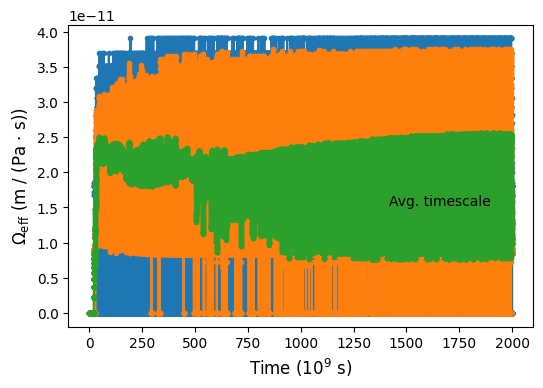

In [ ]:
plt.figure(figsize=(6,4), dpi=100)
# Set window size legend positions
x_anchor = 0.8
y_anchor = 0.10
y_spacing = 0.1
line_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


for i, (n, dt_window, t_center, eff_cond) in enumerate(windowed_eff_cond[:]):
  plt.plot(t_center/1e9, eff_cond, '.-', color=line_colors[i])
plt.xlabel("Time ($10^9$ s)", fontsize=12)
plt.ylabel(r"$\Omega_\mathrm{eff}$ (m / (Pa $\cdot$ s))", fontsize=12)

_xl = plt.xlim()
_yl = plt.ylim()
x_anchor_real = _xl[0] + x_anchor * (_xl[1] - _xl[0])
y_anchor_real = _yl[0] + y_anchor * (_yl[1] - _yl[0])
x_box_width = _yl[0] + y_anchor * (_yl[1] - _yl[0])
y_box_width = 3 * y_spacing * (_yl[1] - _yl[0])

_content_width = 0.0
for i, (n, dt_window, t_center, eff_cond) in enumerate(windowed_eff_cond[:]):
  _x_dat = np.array([x_anchor_real - 0.5 * dt_window/1e9, x_anchor_real + 0.5 * dt_window/1e9])
  _y_dat = (_yl[0] + (y_anchor + i*y_spacing) * (_yl[1] - _yl[0])) * np.ones_like(_x_dat)
  plt.plot(_x_dat, _y_dat, color=line_colors[i])
  _content_width = np.maximum(_content_width, dt_window/1e9)

rect = matplotlib.patches.Rectangle(
  (x_anchor_real - 0.7 * _content_width,
   y_anchor_real - 0.1*y_box_width),
   1.4 * _content_width,
   y_box_width,
   linewidth=1, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
plt.text(x_anchor_real, y_anchor_real + y_box_width, "Avg. timescale", horizontalalignment="center")

### Gaussian Pulse

In [11]:
# Gaussian mass-rate-in function
def gaussian(x, scale=1, mass=1, shift=0.0):
  return np.exp(-0.5 * ((x - shift)/scale)**2) / np.sqrt(2 * np.pi) * mass/scale

mass_in_fn = lambda t, q: gaussian(t, scale=1e9, mass=5e9, shift=5e9)

In [12]:
# Set up for timestepping later
global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                   r_hydr=r_hydr, mu0=mu0, 
                                   rho0=2500, K_f=K_f, Nr=50,
                                   dpdx_crit=1e3,
                                   dpdx_threshold_scale=0.0,#1e2,
                                   R_outer_ratio=20, max_edge_dist=1.1*node_sep)

# Source term due to mass injection at node 0
f_inj = global_sys.create_single_mass_injection_custom(mass_in_fn)
# Source term due to eruption at node -1
f_erupt = global_sys.create_eruption_source(p_erupt=5e6, mu_erupt=1e5, r_conduit=25)



In [18]:
t_vec = np.linspace(0, 5e11, 60000)
q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)

In [19]:
m, p, sigmas, u = global_sys.post_process(t_vec, q_out)

Black dash-dot: shape of mass-in function rescaled and shifted


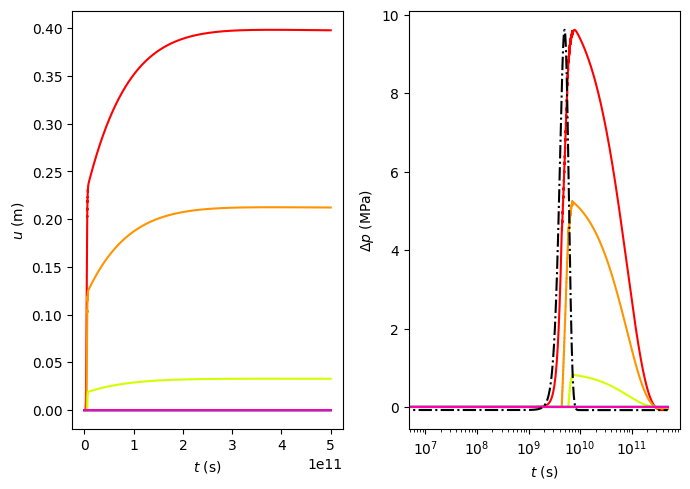

In [29]:
''' Wall displacement, pressure in each chamber '''
fig, ax = plt.subplots(1, 2, figsize=(7,5), dpi=100)
cmap = matplotlib.cm.hsv
colors = cmap(np.linspace(0,1,global_sys.num_blocks,endpoint=False))

for i in range(p.shape[1]):
  ax[0].plot(t_vec, u[:,i,0], color=colors[i])
ax[0].set_xlabel("$t$ (s)")
ax[0].set_ylabel("$u$ (m)")

dp = (p - p[0,:])
for i in range(p.shape[1]):
  ax[1].semilogx(t_vec, dp[:,i] / 1e6, color=colors[i])
ax[1].set_xlabel("$t$ (s)")
ax[1].set_ylabel(r"$\Delta p$ (MPa)")

mass_in_shape = mass_in_fn(t_vec, q_out) / mass_in_fn(t_vec, q_out).max()
_m, _M = dp.min() / 1e6, dp.max() / 1e6
ghost_data = _m + (_M - _m) * mass_in_shape
ax[1].semilogx(t_vec, ghost_data, 'k-.' ) 

fig.tight_layout()
print("Black dash-dot: shape of mass-in function rescaled and shifted")